### Function Transformation

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
# import titanic dataset
data = pd.read_csv('../datasets/titanic2.csv',usecols=['Age','Fare','Survived'])

In [6]:
data.head(3)

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875


In [7]:
# Number of null values
data.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [8]:
# filling null values
data['Age'].fillna(data['Age'].mean(),inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_6656\2702241186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)


In [10]:
data.isnull().sum()

Survived    0
Age         0
Fare        1
dtype: int64

In [11]:
# Filling missing values of fare 
data['Fare'].fillna(data['Fare'].mean(),inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_6656\3130354021.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Fare'].fillna(data['Fare'].mean(),inplace=True)


In [12]:
data.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [13]:
data.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [14]:
x = data.iloc[:,1:3]
y = data.iloc[:,0]

In [15]:
x.head()

,Age,Fare
0,34.5,7.8292
1,47.0,7.0000
2,62.0,9.6875
3,27.0,8.6625
4,22.0,12.2875


In [16]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

In [17]:
### Applying train test split data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [19]:
x_train.shape[0]

292

In [20]:
data.shape[0]

418

In [21]:
y_train.shape[0]

292

In [22]:
x_test.shape[0]

126

###plt.subplot(1, 2, 1)
###           │  │  │
###           │  │  └── Plot number (WHICH one to activate)
###           │  └───── Number of COLUMNS
###           └──────── Number of ROWS

C:\Users\dspri\AppData\Local\Temp\ipykernel_6656\421833682.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


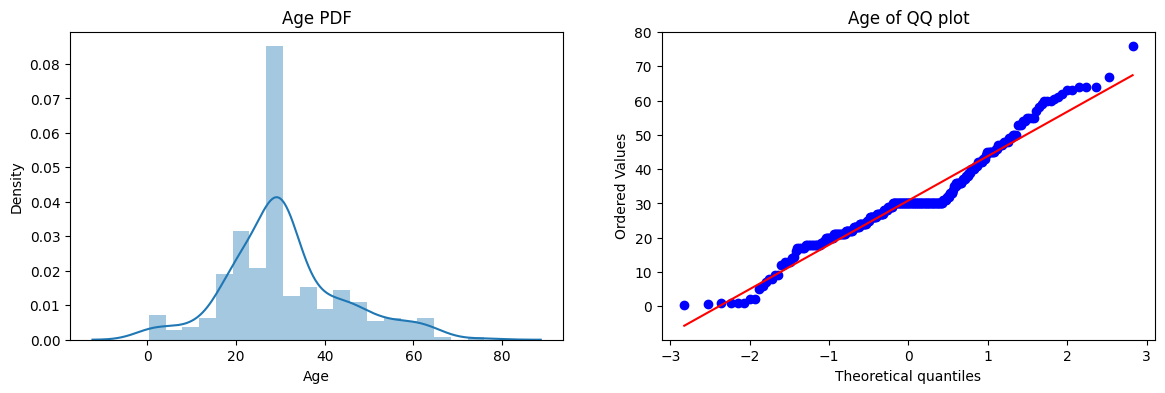

In [24]:
### drawing plot for age column 
# first figure
plt.figure(figsize=(14,4)) # (width,height)
plt.subplot(1,2,1)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

# second figure
plt.subplot(1,2,2)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age of QQ plot')
plt.show()

C:\Users\dspri\AppData\Local\Temp\ipykernel_6656\3711523607.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


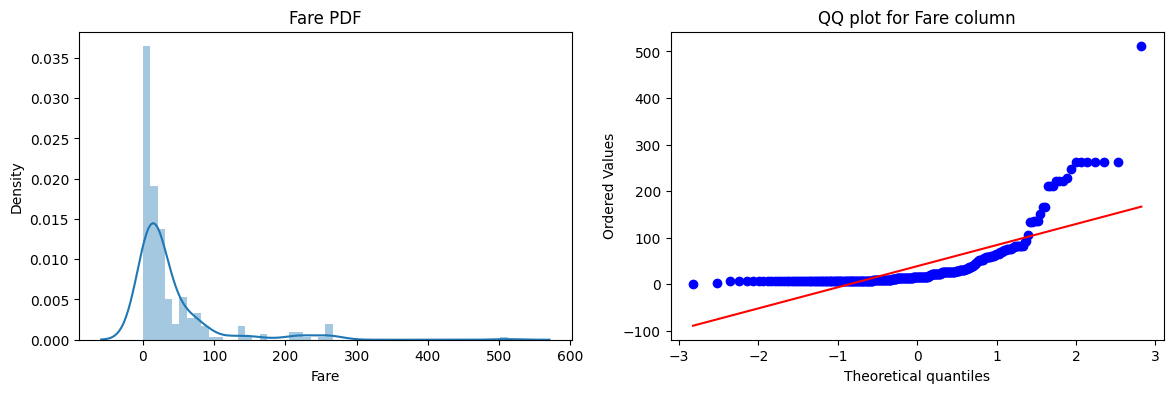

In [26]:
# ckecking whether the fare column is following the normal distribution or not
# figure 1
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

# figure 2
plt.subplot(1,2,2)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('QQ plot for Fare column')
plt.show()


In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [30]:
# cheing the accuracy score of the data by both LogisticRegression and DecisionTreeClassifier
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)

# printing the accuracy score by both the model
print("The accoracy score by LR is : ",accuracy_score(y_test,y_pred))
print("The accuracy score b the DTC model is : ",accuracy_score(y_test,y_pred1))

The accoracy score by LR is :  0.6746031746031746
The accuracy score b the DTC model is :  0.6111111111111112
